In [28]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
#coffea output file
# f_sig = "../coffea/Withxclean_2022/ERE_Withxclean.coffea"  #sample that includes the x-clean loop
f_sig_before = "../coffea/noxclean_beforecodefix/ERE_noxclean_beforeKPfixcode.coffea"
f_sig_after = "../coffea/UpdatedNOxclean_2022/ERE_Updatednoxclean.coffea"

#Nested Dictionary:
sig_histo_before = util.load(f_sig_before) [0]
sig_histo_after = util.load(f_sig_after) [0]



Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
TOTAL number of gen electrons: 128641.0
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
TOTAL number of gen electrons: 128641.0


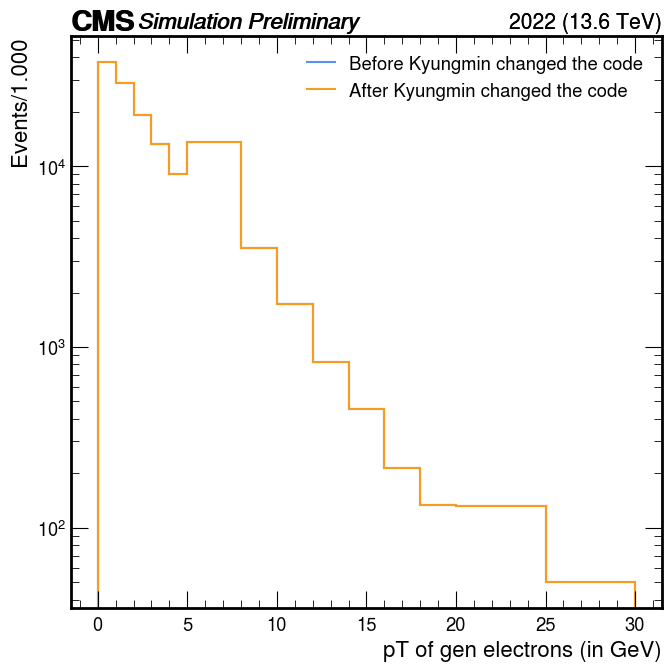

In [30]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_pt',
    'cut': 'cut0',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "pT of gen electrons (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "Before Kyungmin changed the code",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}





results_before = [
    ptools.plot_signal_1D_match(
        sig_histo_before, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )
    # for m1 in m1s
]

counts_before, edges_before = zip(*results_before)

counts_before = np.array(counts_before)     # shape: (n_m1, n_bins)
edges_before  = np.array(edges_before)      # shape: (n_m1, n_edges)


mask_before = counts_before != 0

bins_x_before = (edges_before[:, :-1] + edges_before[:, 1:])*(0.5)

counts_nonzero_den_before = np.where(mask_before, counts_before, np.nan)
edges_nonzero_den_before  = np.where(mask_before, bins_x_before, np.nan)

total_before = np.sum(counts_nonzero_den_before)
print ("TOTAL number of gen electrons:", total_before)

m1=10
delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_pt',
    'cut': 'cut0',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "pT of gen electrons (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "After Kyungmin changed the code",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}





results_after = [
    ptools.plot_signal_1D_match(
        sig_histo_after, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )
    # for m1 in m1s
]
counts_after, edges_after = zip(*results_after)

counts_after = np.array(counts_after)     # shape: (n_m1, n_bins)
edges_after  = np.array(edges_after)      # shape: (n_m1, n_edges)


mask_after = counts_after != 0

bins_x_after = (edges_after[:, :-1] + edges_after[:, 1:])*(0.5)

counts_nonzero_den_after = np.where(mask_after, counts_after, np.nan)
edges_nonzero_den_after  = np.where(mask_after, bins_x_after, np.nan)

total_after = np.sum(counts_nonzero_den_after)
print ("TOTAL number of gen electrons:", total_after)





Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
TOTAL number of low-pT electrons_before: 3737.0
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
TOTAL number of low-pT electrons_after: 4886.0


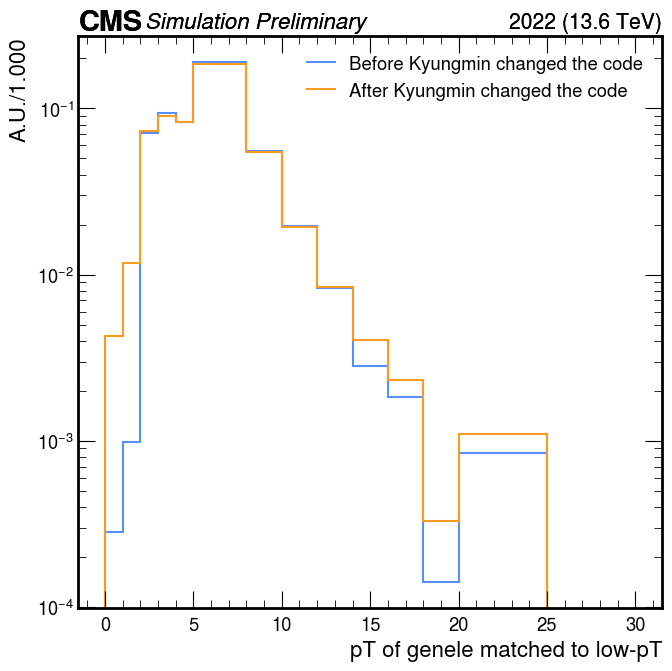

In [31]:
fig, ax = plt.subplots(figsize=(7,7))



plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut0', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to GED",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "Before Kyungmin changed the code"  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1=10
# m1s = [10,30,50]
delta = 0.1
ctau = 10

results_before = [
    ptools.plot_signal_1D_match(
        sig_histo_before, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )
    # for m1 in m1s
]

counts_before, edges_before = zip(*results_before)

counts_num_before = np.array(counts_before)     # shape: (n_m1, n_bins)
edges_num_before = np.array(edges_before)      # shape: (n_m1, n_edges)

bins_x_num_before = (edges_num_before[:, :-1] + edges_num_before[:, 1:])*(0.5)

total_num_before = np.sum(counts_num_before)
print ("TOTAL number of low-pT electrons_before:", total_num_before)


plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut0', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "After Kyungmin changed the code"  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1=10
# m1s = [10,30,50]
delta = 0.1
ctau = 10



results_after = [
    ptools.plot_signal_1D_match(
        sig_histo_after, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )
    # for m1 in m1s
]
counts_after, edges_after = zip(*results_after)

counts_num_after = np.array(counts_after)     # shape: (n_m1, n_bins)
edges_num_after  = np.array(edges_after)      # shape: (n_m1, n_edges)

bins_x_num_after = (edges_num_after[:, :-1] + edges_num_after[:, 1:])*(0.5)

total_num_after = np.sum(counts_num_after)
print ("TOTAL number of low-pT electrons_after:", total_num_after)

In [32]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency_R_before, unc_eff_R_before = eff_determine_unc(counts_num_before, counts_nonzero_den_before)
print (efficiency_R_before)

[[5.30419562e-05 2.43910938e-04 2.59740260e-02 5.00604961e-02
  6.49922891e-02 9.88252570e-02 1.11111111e-01 8.02325581e-02
  7.11700844e-02 4.43458980e-02 6.10328638e-02 7.51879699e-03
  4.58015267e-02 0.00000000e+00]]


In [33]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency_R_after, unc_eff_R_after = eff_determine_unc(counts_num_after, counts_nonzero_den_after)
print ("efficiency_R_after:",efficiency_R_after)
# print ("unc_eff_R:", unc_eff_R)

efficiency_R_after: [[0.00103432 0.00372835 0.03444156 0.06223533 0.08305794 0.12320117
  0.14079729 0.10232558 0.09288299 0.08203991 0.09859155 0.02255639
  0.07633588 0.        ]]


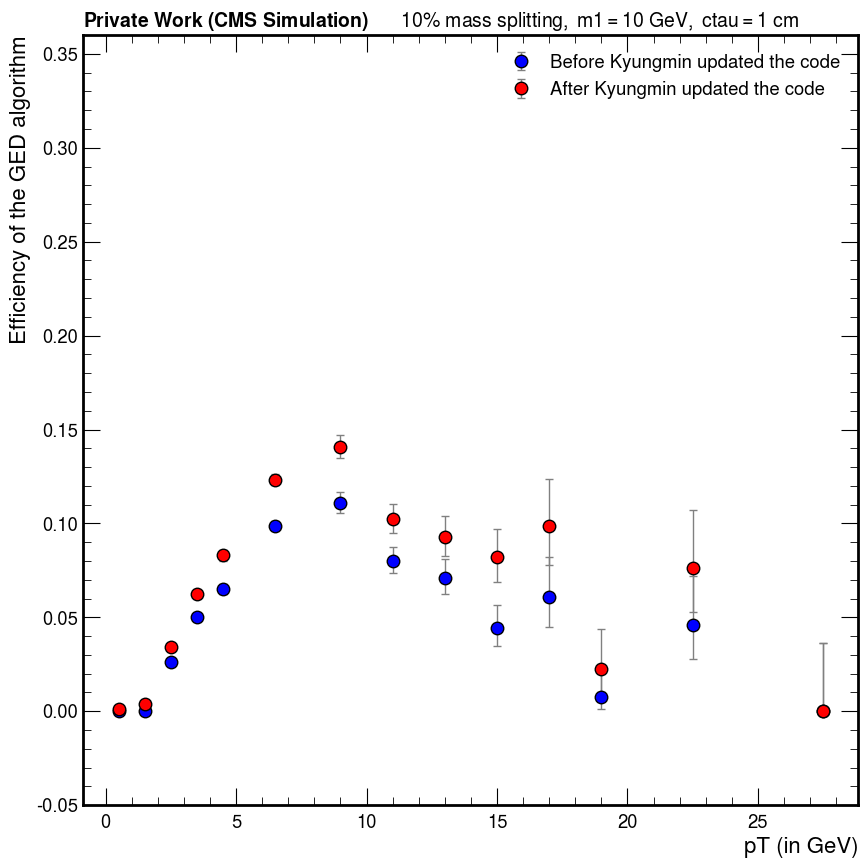

In [34]:
plt.errorbar(
    bins_x_before[0], efficiency_R_before[0],
    yerr=unc_eff_R_before[:,0,:] ,fmt='o', markersize=9, markerfacecolor='blue', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='Before Kyungmin updated the code'  
)
plt.errorbar(
    bins_x_after[0], efficiency_R_after[0],
    yerr=unc_eff_R_after[:,0,:] ,fmt='o', markersize=9, markerfacecolor='red', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='After Kyungmin updated the code'  
)
# plt.errorbar(
#     bins_x[1], efficiency_R[1],
#     yerr=unc_eff_R[:,1,:] ,fmt='o', markersize=9, markerfacecolor='red', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=30 GeV'  
# )

# plt.errorbar(
#     bins_x[2], efficiency_R[2],
#     yerr=unc_eff_R[:,2,:] ,fmt='o', markersize=9, markerfacecolor='yellow', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=50 GeV'  
# )



# plt.xlim(0,30)
plt.ylim(-0.05,0.36)
plt.xlabel("pT (in GeV)")
# plt.ylabel("Efficiency of the GED algorithm")
plt.ylabel("Efficiency of the GED algorithm")

# plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{pT > 20\ GeV}$",
#           fontsize=14, loc='left')

plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting, \ m1 = 10\ GeV, \ ctau = 1\ cm}$",
          fontsize=14, loc='left')

# plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting,\ ctau = 1\ cm}$",
#           fontsize=14, loc='left')


# plt.title("Gen Lxy < 1cm")
plt.legend(loc='upper right')
plt.savefig("L_lxy_ERE.png", dpi=300)
